# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# LOAD DATASET

In [ ]:
df = pd.read_excel(
    "Nata Supermarkets - Customer Analytics Dataset.xlsx",
    sheet_name="marketing"
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# BASIC EDA

In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape of dataset: (2240, 29)

Columns:
 ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe(include="all")

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31-08-2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# DATA CLEANING

In [ ]:
df["Income"] = df["Income"].fillna(df["Income"].median())


In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# FEATURE ENGINEERING

In [ ]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

df["Children"] = df["Kidhome"] + df["Teenhome"]

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchases,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,0,0,0,0,3,11,1,1617,22,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,0,0,0,0,3,11,0,27,4,2
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,776,20,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,0,0,0,0,3,11,0,53,6,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,422,14,1


# EDA: Distribution of Numeric Variables

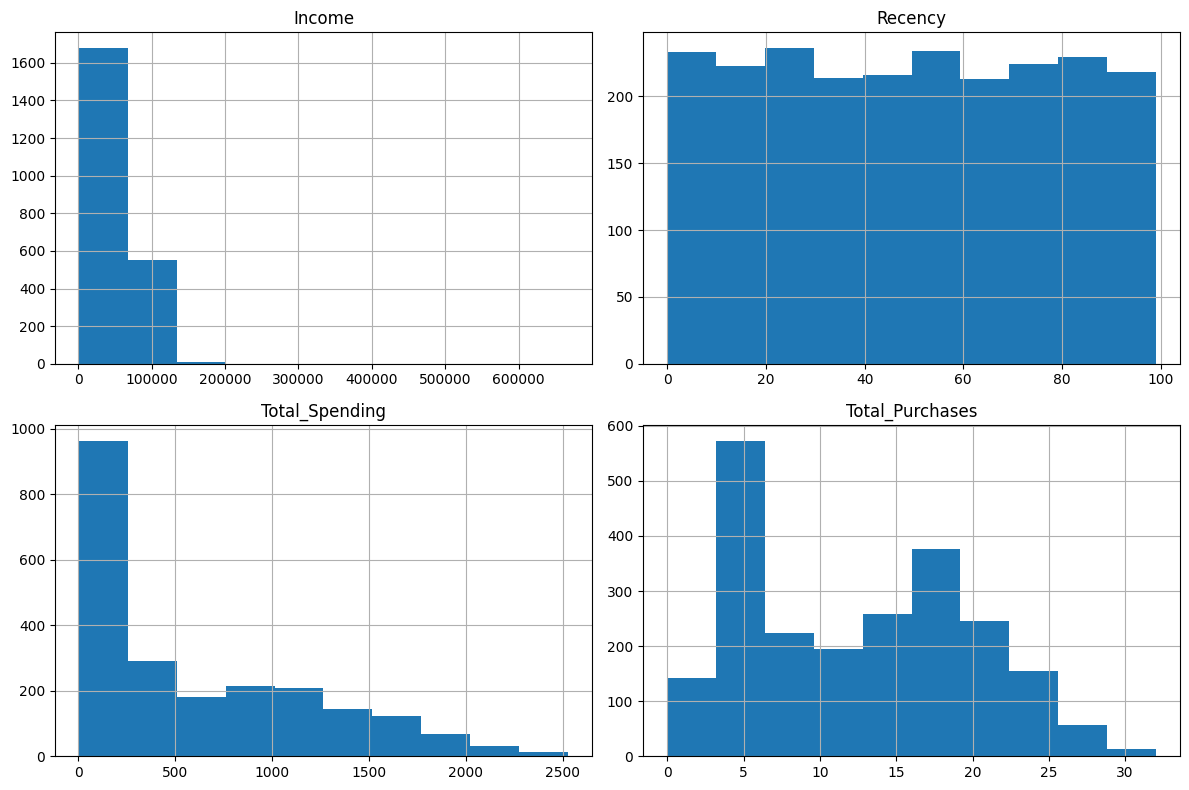

In [ ]:
df[["Income", "Recency", "Total_Spending", "Total_Purchases"]].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# EDA: Product Category Spending

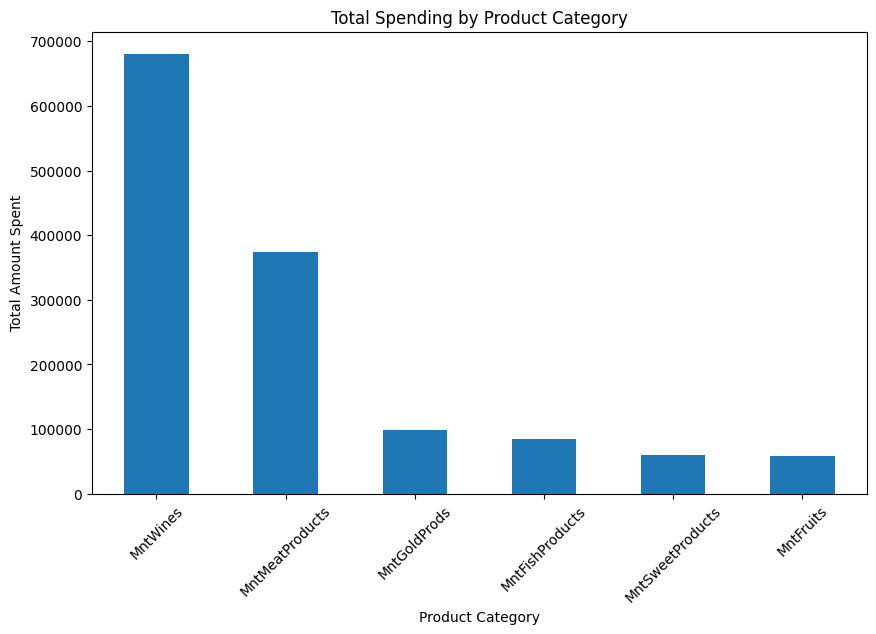

In [ ]:
product_spending = df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
product_spending.plot(kind="bar")
plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.show()

# EDA: Purchase Channel Analysis

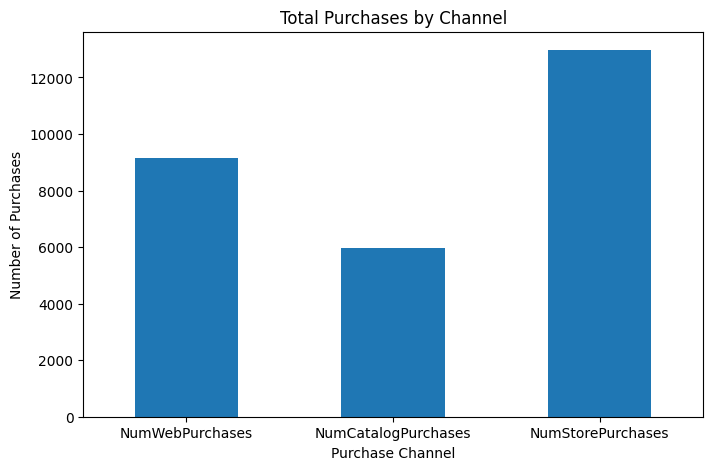

In [ ]:
purchase_channels = df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]].sum()

plt.figure(figsize=(8, 5))
purchase_channels.plot(kind="bar")
plt.title("Total Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)
plt.show()

EDA: Income vs Total Spending

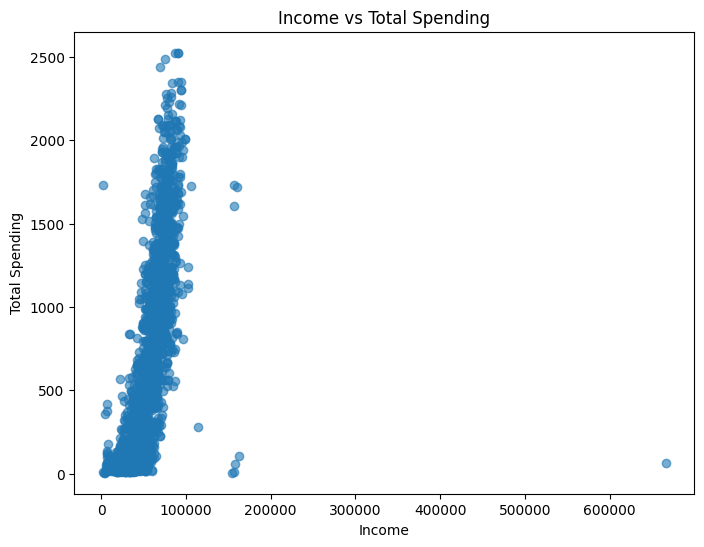

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Income"], df["Total_Spending"], alpha=0.6)
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

# EDA: Recency vs Total Spending

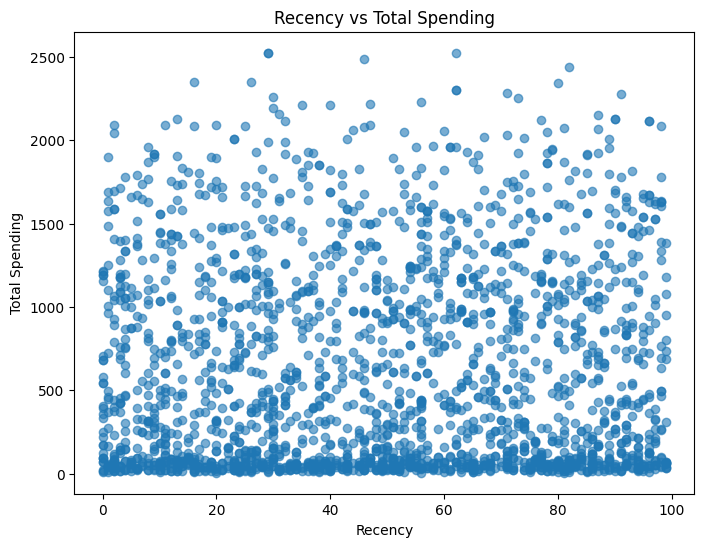

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Recency"], df["Total_Spending"], alpha=0.6)
plt.title("Recency vs Total Spending")
plt.xlabel("Recency")
plt.ylabel("Total Spending")
plt.show()

# EDA: Campaign Response Count

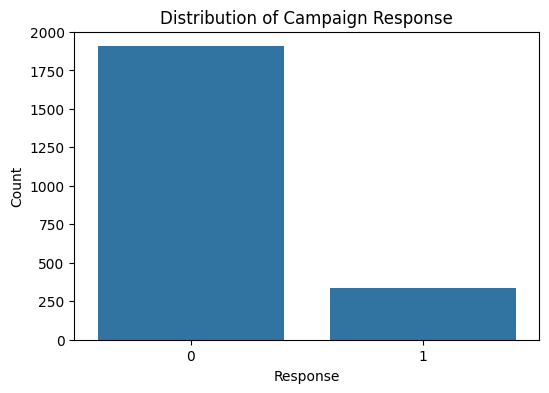

Response
0    1906
1     334
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Response", data=df)
plt.title("Distribution of Campaign Response")
plt.xlabel("Response")
plt.ylabel("Count")
plt.show()

print(df["Response"].value_counts())

# EDA: Correlation Heatmap

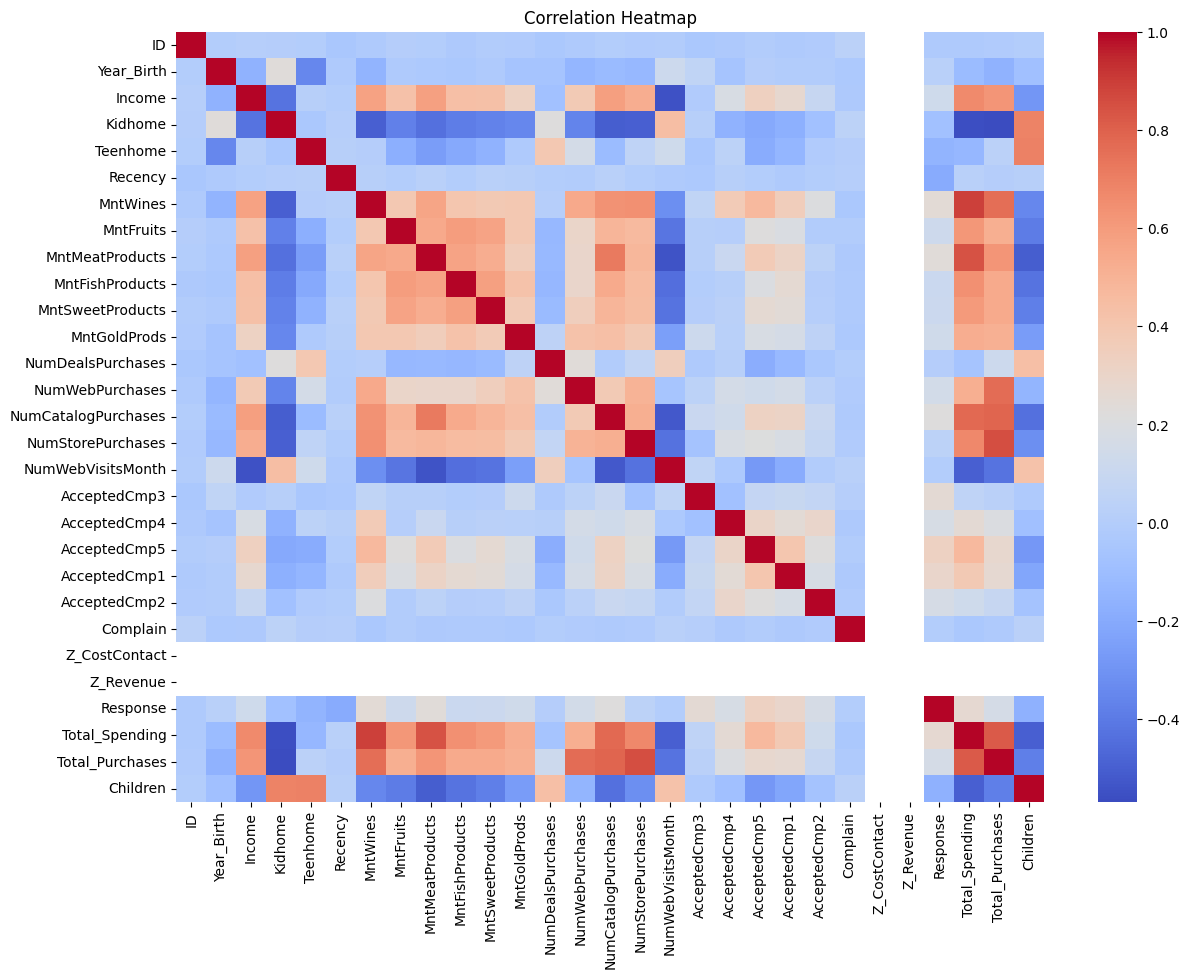

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# EDA: Marital Status and Education

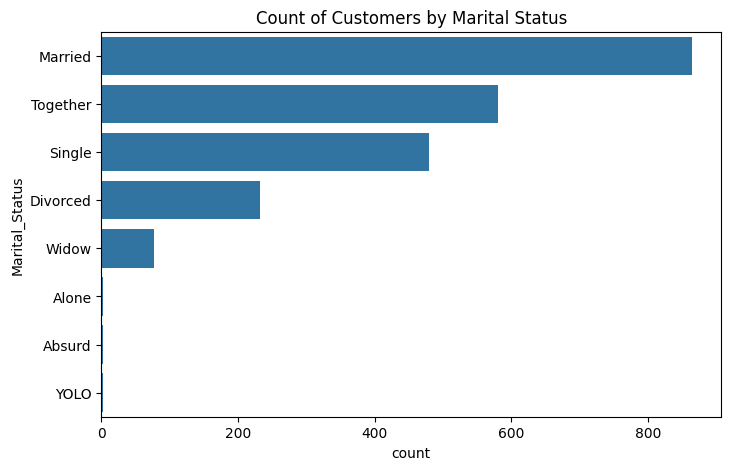

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(y="Marital_Status", data=df, order=df["Marital_Status"].value_counts().index)
plt.title("Count of Customers by Marital Status")
plt.show()

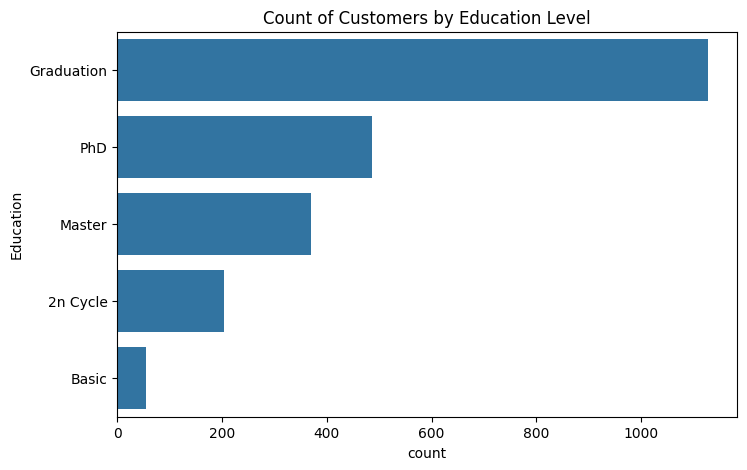

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(y="Education", data=df, order=df["Education"].value_counts().index)
plt.title("Count of Customers by Education Level")
plt.show()

# EDA: Average Spending by Education

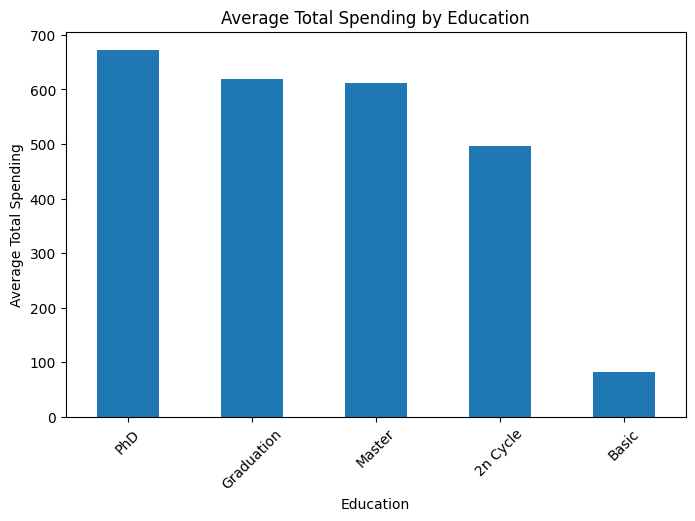

In [ ]:
avg_spending_education = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_spending_education.plot(kind="bar")
plt.title("Average Total Spending by Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

# K-Means Customer Segmentation

In [ ]:
seg_features = df[["Income", "Recency", "Total_Spending"]]

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

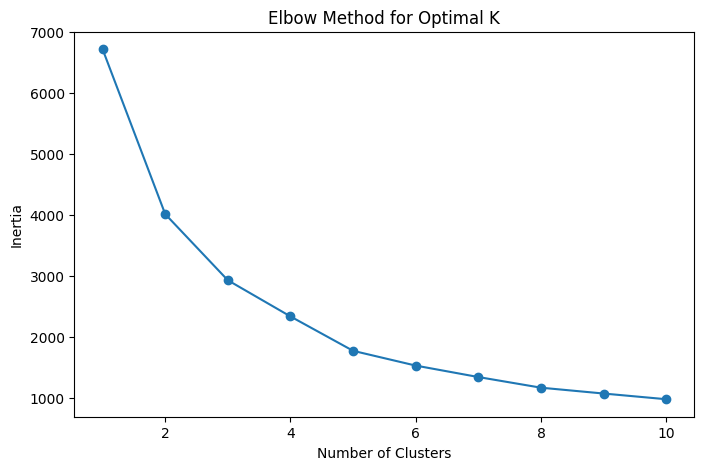

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(seg_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Train K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(seg_scaled)

df[["Income", "Recency", "Total_Spending", "Cluster"]].head()

,Income,Recency,Total_Spending,Cluster
0,58138.0,58,1617,0
1,46344.0,38,27,1
2,71613.0,26,776,0
3,26646.0,26,53,1
4,58293.0,94,422,2


Visualize Clusters

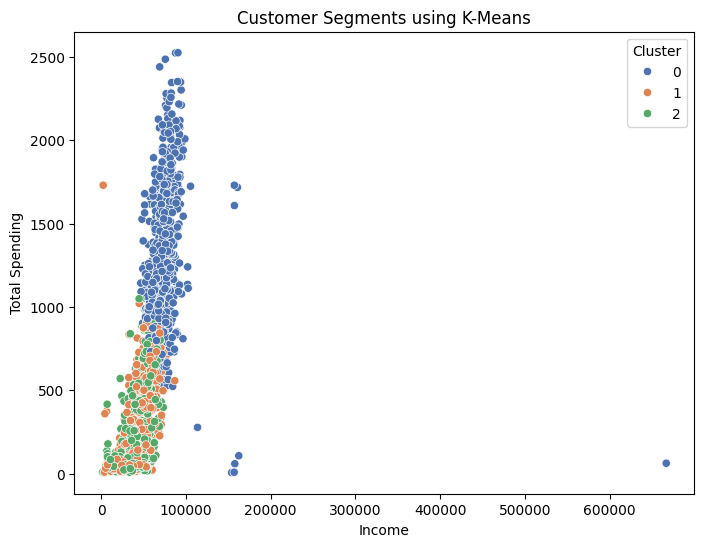

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="deep"
)
plt.title("Customer Segments using K-Means")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

Cluster Summary

In [ ]:
cluster_summary = df.groupby("Cluster")[["Income", "Recency", "Total_Spending", "Total_Purchases"]].mean()
cluster_summary

,Income,Recency,Total_Spending,Total_Purchases
Cluster,,,,
0,74911.697436,50.329487,1313.238462,19.643590
1,40342.810700,22.685871,235.871056,8.916324
2,39907.020520,74.158687,219.852257,8.564979


# Promotion Prediction Model




In [ ]:
model_features = [
    "Income",
    "Recency",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Spending",
    "Children"
]

X = df[model_features]
y = df["Response"]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Train Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Predictions

In [ ]:
y_pred = log_model.predict(X_test)

Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.859375

Confusion Matrix:
 [[371  10]
 [ 53  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       381
           1       0.58      0.21      0.31        67

    accuracy                           0.86       448
   macro avg       0.73      0.59      0.61       448
weighted avg       0.83      0.86      0.83       448



# Feature Importance from Logistic Regression

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
6,NumWebVisitsMonth,0.113912
4,NumCatalogPurchases,0.072426
3,NumWebPurchases,0.051459
2,NumDealsPurchases,0.025699
7,Total_Spending,0.001743
0,Income,-0.000013
1,Recency,-0.027235
5,NumStorePurchases,-0.233607
8,Children,-0.592536


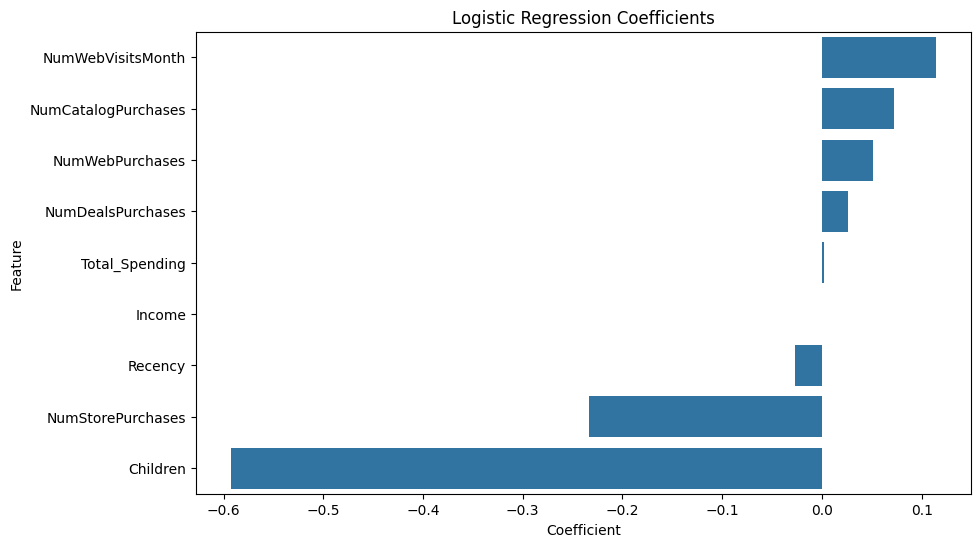

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x="Coefficient", y="Feature")
plt.title("Logistic Regression Coefficients")
plt.show()

In [ ]:
print("Top 5 customers by total spending:")
display(df[["ID", "Income", "Total_Spending", "Response"]].sort_values(by="Total_Spending", ascending=False).head())

print("Average spending by cluster:")
display(df.groupby("Cluster")["Total_Spending"].mean())

print("Average income by cluster:")
display(df.groupby("Cluster")["Income"].mean())

print("Campaign response rate:")
print(df["Response"].mean())

Top 5 customers by total spending:


,ID,Income,Total_Spending,Response
1572,5350,90638.0,2525,1
1179,5735,90638.0,2525,0
1492,1763,87679.0,2524,1
987,4580,75759.0,2486,1
1052,4475,69098.0,2440,0


Average spending by cluster:


,Total_Spending
Cluster,
0,1313.238462
1,235.871056
2,219.852257


Average income by cluster:


,Income
Cluster,
0,74911.697436
1,40342.810700
2,39907.020520


Campaign response rate:
0.14910714285714285
